<img src="./src/logo.png" width="250">

**Baustein:** Datenvorverarbeitung  $\rightarrow$ **Subbaustein:** Grundlagen und unbalanced data $\rightarrow$ **Übungsserie**

**Version:** 1.0, **Lizenz:** <a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/">CC BY-NC-ND 4.0</a>

***

# Datenvorverarbeitung: Grundlagen und unbalanced data

---
## Importieren der notwendigen Python-Bibliotheken

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder

---
## Importieren der Daten
#### Aufgabe 1: Führen Sie die nachfolgenden Zeilen aus, sodass der gewünschte Datensatz *Studierende.csv* in der Variable ```df``` gespeichert wird.
Hierbei hilft die Bibliothek `pandas`, die es erlaubt, zum Beispiel eine `.csv`-Datei als **Dataframe-Objekt** einzulesen. Andere Formate, die mit `pandas` eingelesen werden können sind z.B. `.xlsx`, `.hdf5` oder `.json`.

In [2]:
df = pd.read_csv('./data/Studierende.csv') # Laden des Datensatzes

---
## Datensatz
Machen Sie sich mit dem Datensatz vertraut.
#### Aufgabe 2: Wie groß ist der Datensatz? Was bedeuten die Zeilen und Spalten? Handelt es sich hier um strukturierte Daten?
Der erzeugte Dataframe kann in Jupyter Notebooks so ausgegeben werden:

Antwort: 

In [3]:
display(df) # Ausgabe des dataframe

,Geschlecht,Alter,Wohnort,Ziel hoehere Bildung,Ausbildung der Mutter,Ausbildung des Vaters,woechentliche Lernzeit in h,Nachhilfe,Alkoholkonsum werktags,Alkoholkonsum am Wochenende,Feiern gehen,Freizeit nach der Schule,in einer Beziehung,Note
0,weiblich,18.0,NaN,ja,"hoehere Bildung (Ausbildung, Studium, ...)","hoehere Bildung (Ausbildung, Studium, ...)",2.0,ja,sehr niedrig,sehr niedrig,viel,moderat,nein,durchgefallen
1,weiblich,17.0,Stadt,ja,Grundschule,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,moderat,moderat,nein,durchgefallen
2,weiblich,15.0,Stadt,ja,Grundschule,Grundschule,2.0,ja,niedrig,moderat,wenig,moderat,nein,befriedigend - ausreichend
3,weiblich,15.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",5.-9. Klasse,3.0,nein,sehr niedrig,sehr niedrig,wenig,wenig,ja,sehr gut - gut
4,weiblich,16.0,Stadt,ja,ab der 9. Klasse,ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,moderat,nein,befriedigend - ausreichend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,weiblich,18.0,Stadt,ja,Grundschule,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,sehr wenig,sehr wenig,nein,durchgefallen
967,maennlich,17.0,Stadt,ja,ab der 9. Klasse,Grundschule,1.0,nein,moderat,hoch,sehr viel,viel,nein,befriedigend - ausreichend
968,maennlich,18.0,Land,ja,ab der 9. Klasse,5.-9. Klasse,1.0,nein,moderat,hoch,sehr wenig,viel,nein,befriedigend - ausreichend
969,maennlich,17.0,Land,nein,Grundschule,Grundschule,1.0,nein,moderat,hoch,moderat,wenig,nein,befriedigend - ausreichend


---
## Leerstellen und Duplikate
#### Aufgabe 3: Gibt es im vorliegenden Datensatz Leerstellen oder Duplikate? Untersuchen Sie den Datensatz daraufhingehend und entfernen Sie diese Daten ggf.

In [4]:
df.dropna(inplace=True) # Entfernen von Zeilen mit Leerstelle(n)
df.drop_duplicates(inplace=True) # Entfernen von Duplikaten (behalte erstes Vorkommen)
df

,Geschlecht,Alter,Wohnort,Ziel hoehere Bildung,Ausbildung der Mutter,Ausbildung des Vaters,woechentliche Lernzeit in h,Nachhilfe,Alkoholkonsum werktags,Alkoholkonsum am Wochenende,Feiern gehen,Freizeit nach der Schule,in einer Beziehung,Note
1,weiblich,17.0,Stadt,ja,Grundschule,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,moderat,moderat,nein,durchgefallen
2,weiblich,15.0,Stadt,ja,Grundschule,Grundschule,2.0,ja,niedrig,moderat,wenig,moderat,nein,befriedigend - ausreichend
3,weiblich,15.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",5.-9. Klasse,3.0,nein,sehr niedrig,sehr niedrig,wenig,wenig,ja,sehr gut - gut
4,weiblich,16.0,Stadt,ja,ab der 9. Klasse,ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,moderat,nein,befriedigend - ausreichend
5,maennlich,16.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,viel,nein,sehr gut - gut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,weiblich,17.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",ab der 9. Klasse,2.0,nein,sehr niedrig,sehr niedrig,viel,sehr viel,nein,befriedigend - ausreichend
963,weiblich,18.0,Land,ja,"hoehere Bildung (Ausbildung, Studium, ...)","hoehere Bildung (Ausbildung, Studium, ...)",1.0,nein,niedrig,niedrig,moderat,viel,ja,befriedigend - ausreichend
964,weiblich,19.0,Land,ja,5.-9. Klasse,ab der 9. Klasse,3.0,nein,sehr niedrig,niedrig,wenig,viel,nein,befriedigend - ausreichend
965,weiblich,18.0,Stadt,ja,ab der 9. Klasse,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,viel,moderat,nein,sehr gut - gut


---
## Ausreißer
Wir nehmen an, dass die Daten selbst aufgenommen wurden und wir einen Fehler gemacht haben in der Übertragung der handschriftlichen Tabelle. Für die nachfolgenden Analysen sollen diese Daten daher nicht mit berücksichtigt und damit vom Datensatz entfernt werden. 

**Vorsicht:** Das Entfernen von Datenpunkten nur weil sie nicht zur Hypothese o.ä. passen ist wissenschaftlich schlechtes Verhalten und sollte unter keinen Umständen passieren. Ein Entfernen von Datenpunkten muss immer gut begründet und dokumentiert sein. Außerdem gibt es auch noch andere Möglichkeiten mit Ausreißern umzugehen. 

In diesem Fall nehmen wissen wir, dass wir einen Übertragungsfehler gemacht haben und können die entsprechende Zeile aus dem Datensatz entfernen. 

### Aufgabe 4: Visualisieren Sie sich die metrischen Merkmale mithilfe eines Boxplots. 

Alter                             Axes(0.125,0.11;0.352273x0.77)
woechentliche Lernzeit in h    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

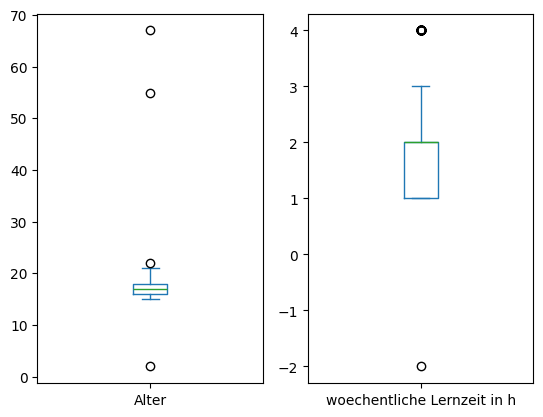

In [5]:
df.plot(kind='box', subplots=True) # Visualisierung der metrischen Merkmale in zwei separaten Boxplots

#### Aufgabe 5: Finden Sie die Ausreißer und entfernen Sie diese. 

In [6]:
idx_alter = df.loc[(df['Alter'] <= 14) | (df['Alter'] >= 25)].index # Finden/Speichern der Indizes, die außerhalb der natürlichen Grenzen des Alters liegen
idx_lernzeit = df.loc[(df['woechentliche Lernzeit in h']<=0)].index # Finden/Speichern der Indizes, die außerhalb der natürlichen Grenzen der Lernzeit liegen

#### Aufgabe 6: Entfernen Sie die Zeile mit dem Ausreißer aus dem Datensatz.

In [7]:
df.drop(idx_alter, inplace=True) # Entfernen aller Zeilen zu den Ausreißern aus dem Merkmal Alter
df.drop(idx_lernzeit, inplace=True) # Entfernen aller Zeilen zu dem Ausreißer aus dem Merkmal Lernzeit in h

In [8]:
display(df)

,Geschlecht,Alter,Wohnort,Ziel hoehere Bildung,Ausbildung der Mutter,Ausbildung des Vaters,woechentliche Lernzeit in h,Nachhilfe,Alkoholkonsum werktags,Alkoholkonsum am Wochenende,Feiern gehen,Freizeit nach der Schule,in einer Beziehung,Note
1,weiblich,17.0,Stadt,ja,Grundschule,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,moderat,moderat,nein,durchgefallen
2,weiblich,15.0,Stadt,ja,Grundschule,Grundschule,2.0,ja,niedrig,moderat,wenig,moderat,nein,befriedigend - ausreichend
3,weiblich,15.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",5.-9. Klasse,3.0,nein,sehr niedrig,sehr niedrig,wenig,wenig,ja,sehr gut - gut
4,weiblich,16.0,Stadt,ja,ab der 9. Klasse,ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,moderat,nein,befriedigend - ausreichend
5,maennlich,16.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,viel,nein,sehr gut - gut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,weiblich,17.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",ab der 9. Klasse,2.0,nein,sehr niedrig,sehr niedrig,viel,sehr viel,nein,befriedigend - ausreichend
963,weiblich,18.0,Land,ja,"hoehere Bildung (Ausbildung, Studium, ...)","hoehere Bildung (Ausbildung, Studium, ...)",1.0,nein,niedrig,niedrig,moderat,viel,ja,befriedigend - ausreichend
964,weiblich,19.0,Land,ja,5.-9. Klasse,ab der 9. Klasse,3.0,nein,sehr niedrig,niedrig,wenig,viel,nein,befriedigend - ausreichend
965,weiblich,18.0,Stadt,ja,ab der 9. Klasse,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,viel,moderat,nein,sehr gut - gut


---
## Normalisierung/Standardisierung
Damit Klassifikationsalgorithmen später bessere Ergebnisse erzielen können, müssen die Daten normalisiert werden.
#### Aufgabe 7: 
Führen Sie vergleichend eine Normalisierung und dann eine Standardisierung der metrischen
Merkmale durch. Vergleichen Sie die größten und kleinsten Werte, Mittelwert und
Standardabweichung der Merkmalsausprägungen vorher und nachher für beide Verfahren. Achten
Sie darauf nicht den originalen dataframe df zu überschreiben.

In [27]:
df_zTransf = df.copy() # kopieren des Datensatzes (ohne dass Veränderungen an df zu Veränderungen an df_zTransf führen)
df_minmaxTransf= df.copy() # kopieren des Datensatzes (ohne dass Veränderungen an df zu Veränderungen an df_zTransf führen)


In [28]:
df.describe() # Ausgabe der deskriptiven Statistik zum Vergleich

,Alter,woechentliche Lernzeit in h
count,791.000000,791.000000
mean,16.792668,1.974716
std,1.244734,0.834004
min,15.000000,1.000000
25%,16.000000,1.000000
50%,17.000000,2.000000
75%,18.000000,2.000000
max,22.000000,4.000000


In [29]:
# Normalisierung/Min-Max-Skalierung
scaler = MinMaxScaler()
df_minmaxTransf['Alter'] = scaler.fit_transform(df_minmaxTransf[['Alter']])
df_minmaxTransf['woechentliche Lernzeit in h'] = scaler.fit_transform(df_minmaxTransf[['woechentliche Lernzeit in h']])
# Standardisierung/z-Transfortmation
scaler = StandardScaler()
df_zTransf['Alter'] = scaler.fit_transform(df_zTransf[['Alter']])
df_zTransf['woechentliche Lernzeit in h'] = scaler.fit_transform(df_zTransf[['woechentliche Lernzeit in h']])

In [30]:
df_minmaxTransf.describe() # Ausgabe der deskriptiven Statistik zu df_minmaxTransf zum Vergleich


,Alter,woechentliche Lernzeit in h
count,791.000000,791.000000
mean,0.256095,0.324905
std,0.177819,0.278001
min,0.000000,0.000000
25%,0.142857,0.000000
50%,0.285714,0.333333
75%,0.428571,0.333333
max,1.000000,1.000000


In [31]:
df_zTransf.describe() # Ausgabe der deskriptiven Statistik zu df_zTransf zum Vergleich

,Alter,woechentliche Lernzeit in h
count,7.910000e+02,7.910000e+02
mean,1.167769e-15,1.976225e-16
std,1.000633e+00,1.000633e+00
min,-1.441112e+00,-1.169458e+00
25%,-6.372195e-01,-1.169458e+00
50%,1.666730e-01,3.033613e-02
75%,9.705655e-01,3.033613e-02
max,4.186136e+00,2.429924e+00


---
## One Hot Encoding und Ordinal Encoding
#### Aufgabe 8:
Wenden Sie das das Ordinal Encoding auf die ordinalen und One-Hot-Encoding auf die nominalen
Merkmalen an. Vergleichen Sie die Anzahl der Merkmale/Spalten und Zeilen vor und nach der
Vorverarbeitung.

In [32]:
# Ordinal Encoding
categories = [['durchgefallen', 'befriedigend - ausreichend', 'sehr gut - gut' ]] # Festlegen der Reihenfolge der Merkmalsausprägungen
scaler = OrdinalEncoder(categories=categories) # Übergeben der Reihenfolge dem erstellten Object des scaler
df_minmaxTransf[['Note']] = scaler.fit_transform(df_minmaxTransf[['Note']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz

categories = [['sehr niedrig', 'niedrig', 'moderat', 'hoch', 'sehr hoch' ]] # Festlegen der Reihenfolge der Merkmalsausprägungen
scaler = OrdinalEncoder(categories=categories) # Übergeben der Reihenfolge dem erstellten Object des scaler
df_minmaxTransf[['Alkoholkonsum werktags']] = scaler.fit_transform(df_minmaxTransf[['Alkoholkonsum werktags']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz
df_minmaxTransf[['Alkoholkonsum am Wochenende']] = scaler.fit_transform(df_minmaxTransf[['Alkoholkonsum am Wochenende']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz

categories = [['sehr wenig', 'wenig', 'moderat', 'viel', 'sehr viel' ]] # Festlegen der Reihenfolge der Merkmalsausprägungen
scaler = OrdinalEncoder(categories=categories) # Übergeben der Reihenfolge dem erstellten Object des scaler
df_minmaxTransf[['Freizeit nach der Schule']] = scaler.fit_transform(df_minmaxTransf[['Freizeit nach der Schule']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz
df_minmaxTransf[['Feiern gehen']] = scaler.fit_transform(df_minmaxTransf[['Feiern gehen']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz

categories = [['Grundschule', '5.-9. Klasse', 'ab der 9. Klasse', 'hoehere Bildung (Ausbildung, Studium, ...)']] # Festlegen der Reihenfolge der Merkmalsausprägungen
scaler = OrdinalEncoder(categories=categories) # Übergeben der Reihenfolge dem erstellten Object des scaler
df_minmaxTransf[['Ausbildung der Mutter']] = scaler.fit_transform(df_minmaxTransf[['Ausbildung der Mutter']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz
df_minmaxTransf[['Ausbildung des Vaters']] = scaler.fit_transform(df_minmaxTransf[['Ausbildung des Vaters']]) # Anpassen und Anwenden der Transformation auf den df_minmaxTransf Datensatz

# One-Hot-Encoding
df_minmaxTransf = pd.get_dummies(df_minmaxTransf) # Anwenden des One-Hot-Encodings auf alle nominalen/kategorischen Merkmale von df_minmaxTransf  

ValueError: Found unknown categories ['keine'] in column 0 during fit

In [19]:
display(df_minmaxTransf)

,Geschlecht,Alter,Wohnort,Ziel hoehere Bildung,Ausbildung der Mutter,Ausbildung des Vaters,woechentliche Lernzeit in h,Nachhilfe,Alkoholkonsum werktags,Alkoholkonsum am Wochenende,Feiern gehen,Freizeit nach der Schule,in einer Beziehung,Note
1,weiblich,17.0,Stadt,ja,Grundschule,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,moderat,2.0,nein,0.0
2,weiblich,15.0,Stadt,ja,Grundschule,Grundschule,2.0,ja,niedrig,moderat,wenig,2.0,nein,1.0
3,weiblich,15.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",5.-9. Klasse,3.0,nein,sehr niedrig,sehr niedrig,wenig,1.0,ja,2.0
4,weiblich,16.0,Stadt,ja,ab der 9. Klasse,ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,2.0,nein,1.0
5,maennlich,16.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",ab der 9. Klasse,2.0,nein,sehr niedrig,niedrig,wenig,3.0,nein,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,weiblich,17.0,Stadt,ja,"hoehere Bildung (Ausbildung, Studium, ...)",ab der 9. Klasse,2.0,nein,sehr niedrig,sehr niedrig,viel,4.0,nein,1.0
963,weiblich,18.0,Land,ja,"hoehere Bildung (Ausbildung, Studium, ...)","hoehere Bildung (Ausbildung, Studium, ...)",1.0,nein,niedrig,niedrig,moderat,3.0,ja,1.0
964,weiblich,19.0,Land,ja,5.-9. Klasse,ab der 9. Klasse,3.0,nein,sehr niedrig,niedrig,wenig,3.0,nein,1.0
965,weiblich,18.0,Stadt,ja,ab der 9. Klasse,Grundschule,2.0,nein,sehr niedrig,sehr niedrig,viel,2.0,nein,2.0


---

<a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/"><img alt="Creative Commons Lizenzvertrag" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-nd/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title">Die Übungsserie begleitend zum AI4ALL-Kurs</span> der <span xmlns:cc="http://creativecommons.org/ns#" property="cc:attributionName">EAH Jena</span> ist lizenziert unter einer <a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/">Creative Commons Namensnennung - Nicht kommerziell - Keine Bearbeitungen 4.0 International Lizenz</a>.

Der AI4ALL-Kurs entsteht im Rahmen des Projekts MoVeKI2EAH. Das Projekt MoVeKI2EAH wird durch das BMBF (Bundesministerium für Bildung und Forschung) und den Freistaat Thüringen im Rahmen der Bund-Länder-Initiative zur Förderung von Künstlicher Intelligenz in der Hochschulbildung gefördert (12/2021 bis 11/2025, Föderkennzeichen 16DHBKI081).